In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [78]:
df = pd.read_csv('../data/raw/telco_churn.csv')

In [79]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [80]:
df.shape

(7043, 21)

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [82]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [83]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

<Axes: xlabel='gender', ylabel='count'>

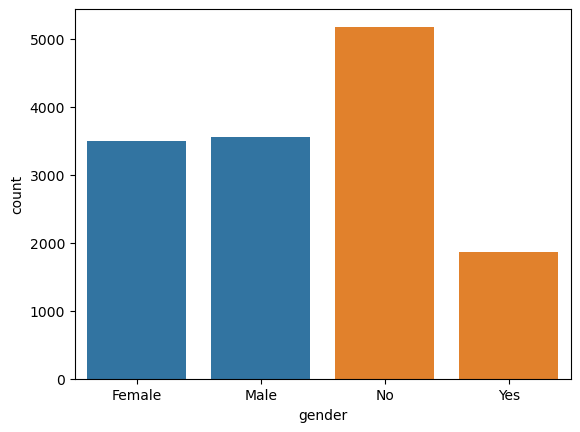

In [84]:
sns.countplot(x='gender', data=df)
sns.countplot(x='Churn', data=df)

In [85]:
df['Churn'].value_counts() #imbalanced

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [86]:
df['TotalCharges'].dtype

dtype('O')

In [87]:
mask = df['TotalCharges'].apply(lambda x: isinstance(x,str) and x.strip()=='')
print("Empty String count: ",mask.sum())


Empty String count:  11


In [88]:
df.loc[mask,['customerID','TotalCharges', 'tenure', 'MonthlyCharges']]

,customerID,TotalCharges,tenure,MonthlyCharges
488,4472-LVYGI,,0,52.55
753,3115-CZMZD,,0,20.25
936,5709-LVOEQ,,0,80.85
1082,4367-NUYAO,,0,25.75
1340,1371-DWPAZ,,0,56.05
3331,7644-OMVMY,,0,19.85
3826,3213-VVOLG,,0,25.35
4380,2520-SGTTA,,0,20.00
5218,2923-ARZLG,,0,19.70
6670,4075-WKNIU,,0,73.35


In [89]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')
df['TotalCharges'].isna().sum()

11

In [90]:
df['TotalCharges'].fillna(df['TotalCharges'].median(),inplace=True)


/var/folders/m9/rns_73l10vl4v8dj6j2vt6mm0000gn/T/ipykernel_55594/1904720698.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(),inplace=True)


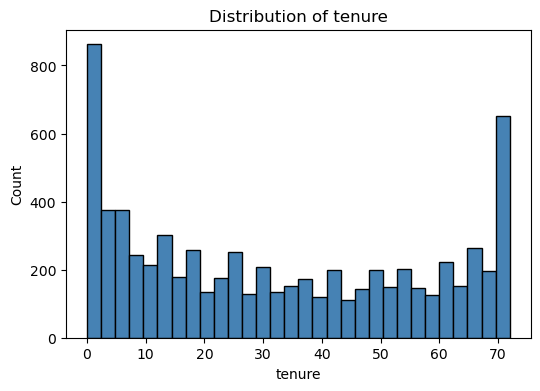

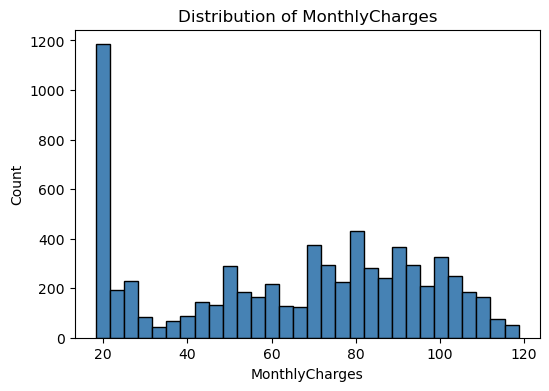

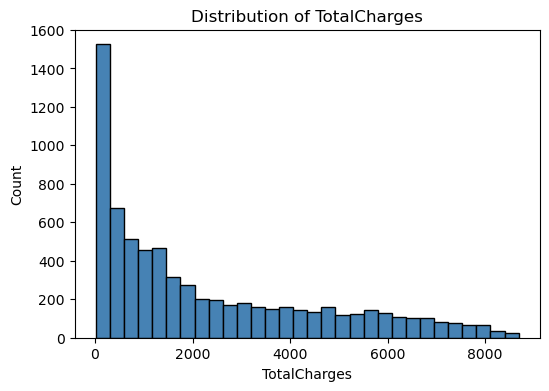

In [91]:
numeric_cols = ['tenure','MonthlyCharges','TotalCharges']

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=30, color='steelblue', edgecolor='black')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

In [92]:
df['Churn'].unique()

array(['No', 'Yes'], dtype=object)

In [93]:
df['Churn_Flag'] = df['Churn'].map({'Yes':1,'No':0})

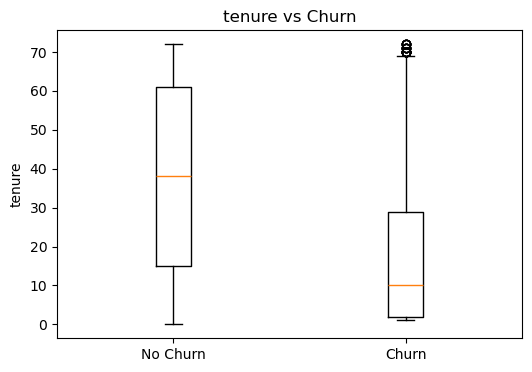

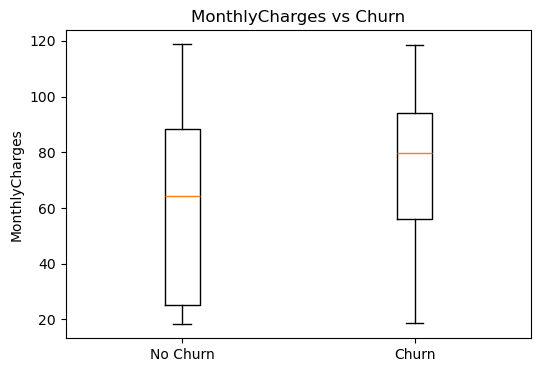

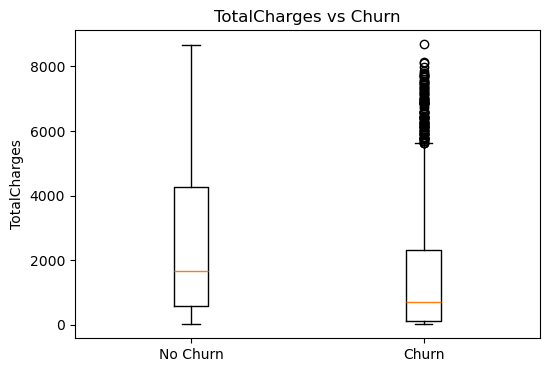

In [98]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.boxplot([df[df['Churn_Flag']==0][col], df[df['Churn_Flag']==1][col]],
                labels=['No Churn', 'Churn'])
    plt.title(f"{col} vs Churn")
    plt.ylabel(col)
    plt.show()

In [99]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Flag
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0


In [115]:
df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})
print(df['gender'].head())

0    1
1    0
2    0
3    0
4    1
Name: gender, dtype: int64


In [116]:
df['gender'].value_counts()

gender
0    3555
1    3488
Name: count, dtype: int64

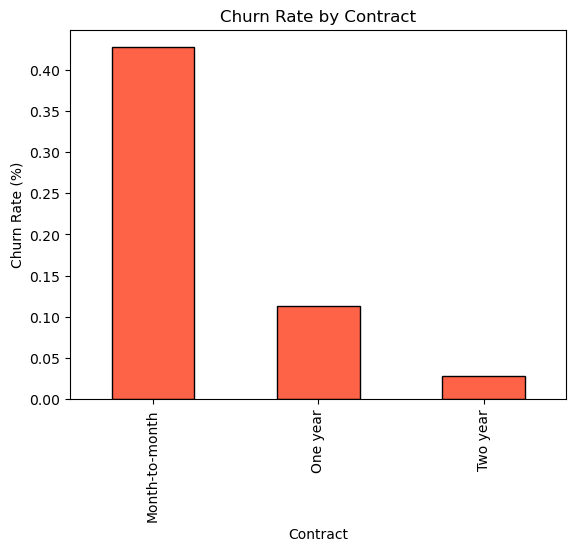

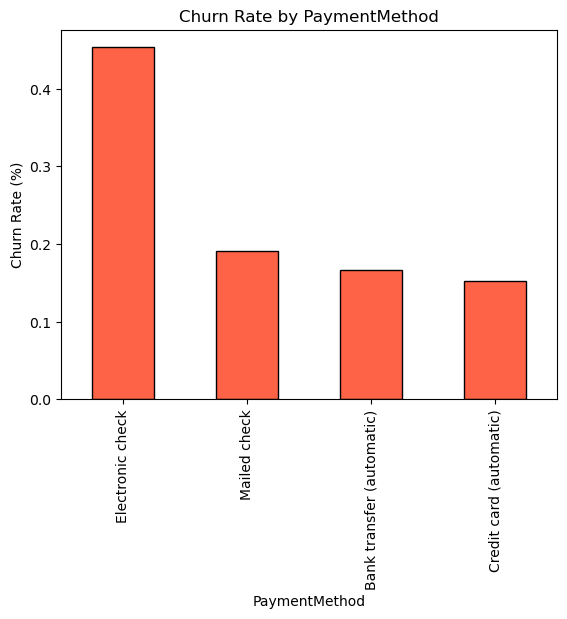

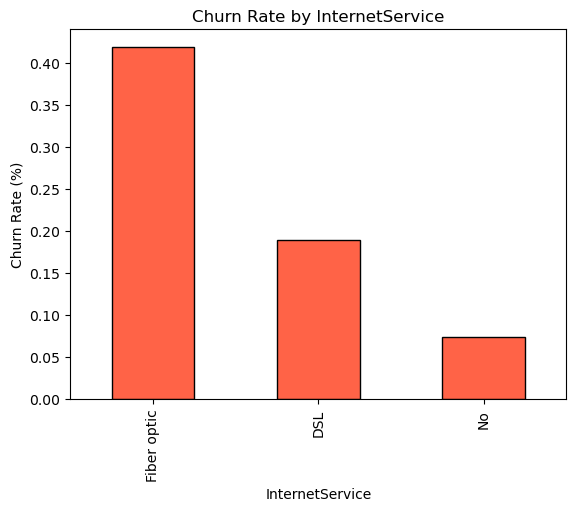

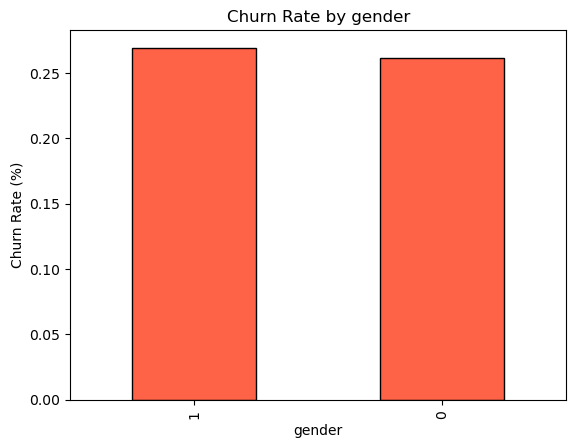

In [117]:
categorical_cols = ['Contract', 'PaymentMethod', 'InternetService', 'gender']

for col in categorical_cols:
    churn_rate = df.groupby(col)['Churn_Flag'].mean().sort_values(ascending=False)
    churn_rate.plot(kind='bar', color='tomato', edgecolor='black')
    plt.title(f"Churn Rate by {col}")
    plt.ylabel("Churn Rate (%)")
    plt.show()

In [118]:
corr = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Flag']].corr()
print(corr)

                  tenure  MonthlyCharges  TotalCharges  Churn_Flag
tenure          1.000000        0.247900      0.825464   -0.352229
MonthlyCharges  0.247900        1.000000      0.650864    0.193356
TotalCharges    0.825464        0.650864      1.000000   -0.199037
Churn_Flag     -0.352229        0.193356     -0.199037    1.000000


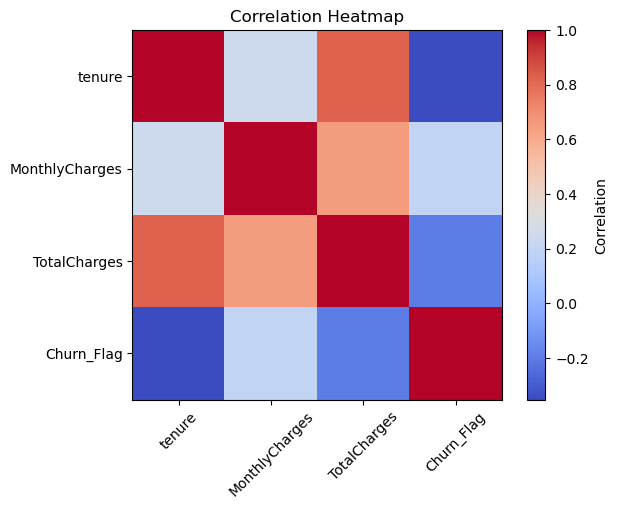

In [120]:
plt.imshow(corr, cmap='coolwarm', interpolation='none')
plt.colorbar(label='Correlation')
plt.title("Correlation Heatmap")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show()

### Insights
- Around 26% of customers have churned.
- Month-to-month contracts have the highest churn.
- Customers with higher monthly charges churn more.
- Long-term customers (higher tenure) churn less.
- Fiber optic users show higher churn than DSL users.

In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   int64  
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 
